# Running Inference with Hi-Scooby

This tutorial notebook gives an example of hwo to generate 5 kb and pooled sparse 10 kb chromatin contact-map predictions from a wide single-cell RNA-count table.

It will guide also guide you through installing required software and visualizing the resulting contact maps.

## Step 1: Installation
We first install Hi-Scooby and AlphaGenome dependencies.
First, ensure you've created the hi-scooby environment and separate RNA-encoding environment:

In [1]:
%conda env update -f environment.yml

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done
Installing pip dependencies: - Ran pip subprocess with arguments:
['/home/p.cody/miniconda3/envs/hi-scooby/bin/python', '-m', 'pip', 'install', '-U', '-r', '/storage2/fs1/syidan/Active/scooby_test/hi-scooby/condaenv.86ci9bh9.requirements.txt', '--exists-action=b']
Pip subprocess output:
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu126
  Cloning https://github.com/google-deepmind/alphagenome_research.git (to revision 455009019acd4c816873d648404ffef2d506606c) to /tmp/pip-install-g977ffrv/alphagenome-research_b62da3a4a8734f13994dc2bc9cf7e6a5
  Resolved https://github.com/google-deepmind/alphagenome_research.git to commit 455009019acd4c816873d648404ffef2d506606c
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting r

In [2]:
import os

os.environ["PYTHONNOUSERSITE"] = "1"
%conda env update -f environment-rna.yml

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done
Installing pip dependencies: | Ran pip subprocess with arguments:
['/home/p.cody/miniconda3/envs/hi-scooby-rna/bin/python', '-m', 'pip', 'install', '-U', '-r', '/storage2/fs1/syidan/Active/scooby_test/hi-scooby/condaenv.2sjygpr3.requirements.txt', '--exists-action=b']
Pip subprocess output:
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121

done
#
# To activate this environment, use
#
#     $ conda activate hi-scooby-rna
#
# To deactivate an active environment, use
#
#     $ conda deactivate


Note: you may need to restart the kernel to use updated packages.


And set the hi-scooby environment to the notebook kernel before running proceeding cells.

In [3]:
from pathlib import Path

repo_root = Path.cwd()
%pip install -q -e {repo_root}

Note: you may need to restart the kernel to use updated packages.


## Step 2: Path Configuration

For this tutorial, we're using an example RNA dataset from the original scHiCAR experiment (Wei, 26) and accompanying mouse reference resources.

For personal usage, replace:
- `RNA_COUNTS` with a gzipped wide RNA-count TSV whose first columns are `barcode` and `cell_type`.
- `RESOURCE_ROOT` with the directory containing the required `data/...` resource layout described in the repository README.

The trained Hi-Scooby heads are included with the package. AlphaGenome model weights are downloaded automatically from Hugging Face on first use.

Note: `OUTPUT_DIR` must not already exist because Hi-Scooby never overwrites an inference run.

In [4]:
from hi_scooby.resources import load_resources
import pandas as pd

RNA_COUNTS = Path(
    "/storage2/fs1/syidan/Active/scooby_test/new_data_withRNA/"
    "rna_counts_3879cells_with_celltype.tsv.gz" # REPLACE WITH YOUR OWN RNA TSV!
)

RESOURCE_ROOT = Path(
    "/storage2/fs1/syidan/Active/scooby_test/scoo-hic" # REPLACE WITH YOUR OWN RESOURCE ROOT!
)

OUTPUT_DIR = repo_root / "tutorial_output" # REPLACE IF YOU DESIRE ANOTHER OUTPUT DIR!

resources = load_resources()
contexts = pd.read_parquet(
    resources.resolve("phase1_target_contexts")
)

POOLED_REFERENCE_DEPTH = int(contexts["valid_pairs"].sum())

os.environ["HI_SCOOBY_RESOURCE_ROOT"] = str(RESOURCE_ROOT)

[resources] phase1_target_contexts: /storage2/fs1/syidan/Active/scooby_test/scoo-hic/data/processed/multiome_rna/target_contexts.parquet


Hi-Scooby first validates the table structure and summarizes the cells, genes, cell types, and sequencing libraries present in the RNA dataset. Make sure you're data looks right!

In [5]:
from hi_scooby.rna import inspect_wide_rna

rna = inspect_wide_rna(RNA_COUNTS)

print(f"Cells:       {rna.n_cells:,}")
print(f"Genes:       {rna.n_genes:,}")
print(f"Cell types:  {len(rna.cell_type_counts)}")
print(f"Libraries:   {len(rna.library_ids)}")

Validating RNA: 3879cells [00:00, 7744.83cells/s]


Cells:       3,879
Genes:       23,075
Cell types:  22
Libraries:   39


## Step 3: Run Hi-Scooby Inference

The command below runs both inference branches. On first use, AlphaGenome downloads its pinned model weights and compiles the sequence forward pass. Subsequent runs can reuse the local model cache.

The resulting Zarr and Parquet files are written to `OUTPUT_DIR`.

Note: The code block below runs inference on the first n tiles. I recommend running the example tiles
before proceeding with the full dataset. After confirming the example, run complete genome-wide inference with:

```bash
hi-scooby predict /path/to/rna_counts.tsv.gz --output /path/to/output
```

In [10]:
from hi_scooby.inference.runner import run_inference

run_inference(
    RNA_COUNTS,
    OUTPUT_DIR,
    mode="both",
    contact_depth=POOLED_REFERENCE_DEPTH,
    seed=0,
    tile_limit=18,
)

Validating RNA: 3879cells [00:00, 7751.43cells/s]

[resources] phase1_tiles: /storage2/fs1/syidan/Active/scooby_test/scoo-hic/data/processed/multiome/tiles.parquet
[resources] sparse_tiles: /storage2/fs1/syidan/Active/scooby_test/scoo-hic/data/processed/raw_contact_ranker_10kb_inputs/tiles.10kb.parquet


[resources] phase1_v2_checkpoint: /storage2/fs1/syidan/Active/scooby_test/hi-scooby/models/phase1_v2/best.pt
[smooth] Loading phase-1 v2 checkpoint on cuda
[smooth] Ready: 102,271 parameters; 20 trained contexts
[resources] rna_scvi_14_model: /storage2/fs1/syidan/Active/scooby_test/hi-scooby/models/rna_scvi_14
[RNA-SCVI] Starting isolated historical-environment inference
[RNA-SCVI 1/4] Validating and aligning RNA counts


Validating RNA: 3879cells [00:00, 8117.57cells/s]
Loading RNA counts: 100%|██████████| 3879/3879 [00:02<00:00, 1659.78cells/s]
/home/p.cody/miniconda3/envs/hi-scooby-rna/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /storage2/fs1/syidan/Active/scooby_test/hi-scooby/sr ...
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[RNA-SCVI 2/4] Constructing query AnnData
[RNA-SCVI 3/4] Loading frozen encoder on CPU
INFO     File                                                                   
         /storage2/fs1/syidan/Active/scooby_test/hi-scooby/models/rna_scvi_14/mo
         del.pt already downloaded                                              
[RNA-SCVI 4/4] Aggregating and saving cell-type centroids
[RNA-SCVI] Wrote 22 cell-type centroids covering 3,879 cells: /tmp/hi_scooby_rna_328pibrx/centroids.parquet
[smooth] Omitting cell types outside the 20 trained target contexts: CLA, Meis2
[resources] sparse_distance_offsets: /storage2/fs1/syidan/Active/scooby_test/scoo-hic/data/processed/raw_contact_ranker_10kb_v1/distance_offset_curve.parquet
[resources] sparse_10kb_checkpoint: /storage2/fs1/syidan/Active/scooby_test/hi-scooby/models/sparse_10kb_v1/best.pt
[resources] sparse_calibration: /storage2/fs1/syidan/Active/scooby_test/hi-scooby/configs/sparse_10kb_calibration.yaml
[sparse] Loading diagnostic 10 

...

Sequence windows and contact heads:  94%

[smooth] Decoding 20 context map(s)


Sequence windows and contact heads: 100%
Render sparse visualization maps: 100%|█

[output] Published validated run: /storage2/fs1/syidan/Active/scooby_test/hi-scooby/tutorial_output


PosixPath('/storage2/fs1/syidan/Active/scooby_test/hi-scooby/tutorial_output')

## Step 4: Visualize predictions

Hi-Scooby stores dense visualization maps in Zarr, canonical sparse predictions in Parquet, and the genomic coordinates and RNA contexts in accompanying tables.

The smoothed branch predicts one contact map for each supported RNA context. Here we display an example predicted context from the example tiles.

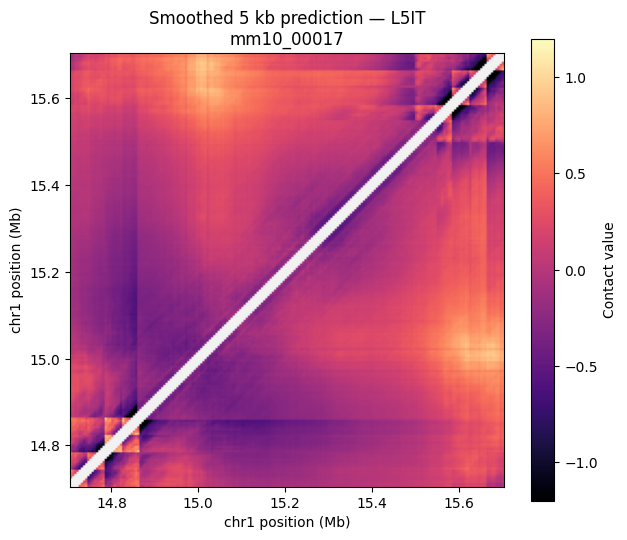

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import zarr

maps = zarr.open_group(OUTPUT_DIR / "contact_maps.zarr", mode="r")
tiles = pd.read_parquet(OUTPUT_DIR / "tiles.parquet")

tile_id = "mm10_00017"
context = "L5IT"

tile_index = int(np.flatnonzero(tiles["tile_id"].eq(tile_id))[0])
context_ids = list(maps["smooth"].attrs["context_ids"])
context_index = context_ids.index(context)
tile = tiles.iloc[tile_index]

contact_map = maps["smooth/signed_log_observed_expected"][
    context_index, tile_index
]
valid = maps["smooth/valid_mask"][tile_index]
contact_map = np.where(valid, contact_map, np.nan)

start = tile["smooth_target_start"] / 1e6
end = tile["smooth_target_end"] / 1e6
cmap = plt.colormaps["magma"].copy()
cmap.set_bad("#f2f2f2")

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(
    contact_map,
    origin="lower",
    extent=(start, end, start, end),
    cmap=cmap,
    vmin=-1.2,
    vmax=1.2,
)

ax.set_title(f"Smoothed 5 kb prediction — {context}\n{tile_id}")
ax.set_xlabel(f"{tile['chrom']} position (Mb)")
ax.set_ylabel(f"{tile['chrom']} position (Mb)")
fig.colorbar(image, ax=ax, label="Contact value")
plt.show()

The sparse head outputs a pooled sparse expectation. There is also the option to visualize a simulated count realization.

/tmp/ipykernel_1969404/851761433.py:20: RuntimeWarning: divide by zero encountered in log1p
  simulated_plot = np.where(upper, np.log1p(simulated), np.nan)


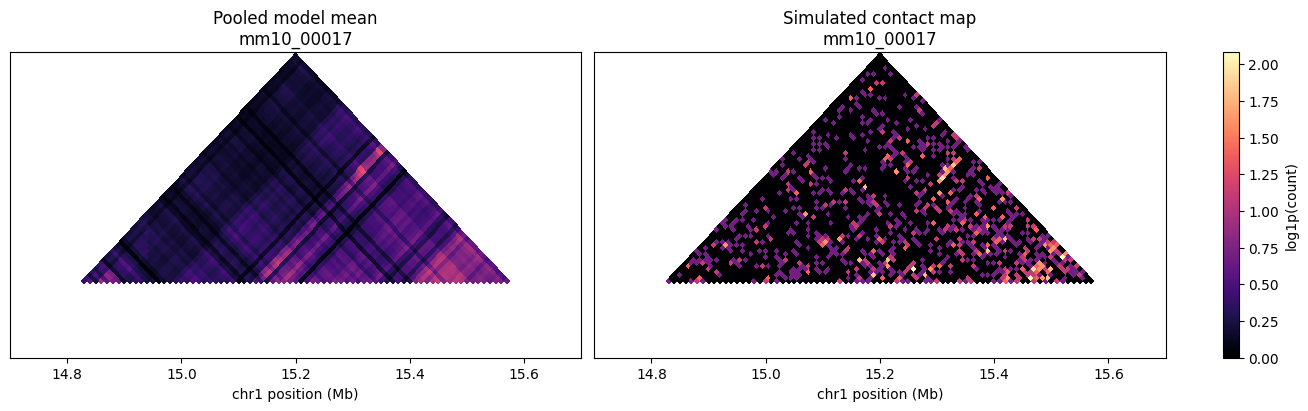

In [13]:
tile_id = "mm10_00017"
tile_index = int(np.flatnonzero(tiles["tile_id"].eq(tile_id))[0])
tile = tiles.iloc[tile_index]

valid = maps["sparse/valid_mask"][tile_index]
upper = np.triu(valid, k=1)

expected = maps["sparse/expected_count"][0, tile_index]
simulated = maps["sparse/simulated_count"][0, tile_index]

start = tile["sparse_target_start"] / 1e6
end = tile["sparse_target_end"] / 1e6
edges = np.linspace(start, end, expected.shape[0] + 1)
x, y = np.meshgrid(edges, edges)

rotated_x = (x + y) / 2
rotated_y = (x - y) / 2

expected_plot = np.where(upper, np.log1p(expected), np.nan)
simulated_plot = np.where(upper, np.log1p(simulated), np.nan)
vmax = max(np.nanmax(expected_plot), np.nanmax(simulated_plot))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

for ax, values, title in [
    (axes[0], expected_plot, "Pooled model mean"),
    (axes[1], simulated_plot, "Simulated contact map"),
]:
    image = ax.pcolormesh(
        rotated_x,
        rotated_y,
        values,
        cmap="magma",
        vmin=0,
        vmax=vmax,
        shading="auto",
    )
    ax.set_xlim(start, end)
    ax.set_ylim(0, (end - start) / 2)
    ax.set_title(f"{title}\n{tile_id}")
    ax.set_xlabel(f"{tile['chrom']} position (Mb)")
    ax.set_yticks([])

fig.colorbar(image, ax=axes, label="log1p(count)")
plt.show()